# Demographic, socioeconomic, and testing composition of the six largest pre-L2 Alpha meta-clusters

This notebook starts from the pre-L2 Alpha meta-cluster assignments created in `alpha_pre_l2_meta_cluster_network.ipynb`. It focuses on the six largest meta-clusters and describes their composition over calendar time using **one row per unique sequence**, not overlapping rolling-window rows.

The summaries are descriptive. Small meta-clusters have sparse weekly counts, so the time-varying proportions should be read as exploratory signals rather than stable estimates.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root(start: Path = Path.cwd()) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root containing config.yaml and data/.")


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils import style

style.set_theme(font_scale=0.9)
ROOT


PosixPath('/Users/ydnkka/Desktop/PhD Project/projects/scotland')

In [2]:
ANALYSIS_DATASET = ROOT / "data/processed/scotland_clustering_analysis_dataset.parquet"

TOP_N_META_CLUSTERS = 6
PRIMARY_RESOLUTION = 0.3
PRIMARY_QC = "good"

# Previous notebook output locations. The first existing directory is used.
META_TABLE_DIR_CANDIDATES = [
    ROOT / "part3/notebooks/tables",
    ROOT / "part3/tables/alpha_meta_clusters",
]
META_TABLE_DIR = next((path for path in META_TABLE_DIR_CANDIDATES if (path / "alpha_pre_l2_meta_cluster_summary.csv").exists()), None)
if META_TABLE_DIR is None:
    raise FileNotFoundError("Run alpha_pre_l2_meta_cluster_network.ipynb first; meta-cluster tables were not found.")

OUTPUT_TABLE_DIR = ROOT / "part3/notebooks/tables"
OUTPUT_FIGURE_DIR = ROOT / "part3/notebooks/figures"
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Using meta-cluster tables from: {META_TABLE_DIR}")
print(f"Writing tables to: {OUTPUT_TABLE_DIR}")
print(f"Writing figures to: {OUTPUT_FIGURE_DIR}")


Using meta-cluster tables from: /Users/ydnkka/Desktop/PhD Project/projects/scotland/part3/notebooks/tables
Writing tables to: /Users/ydnkka/Desktop/PhD Project/projects/scotland/part3/notebooks/tables
Writing figures to: /Users/ydnkka/Desktop/PhD Project/projects/scotland/part3/notebooks/figures


In [3]:
AGE_BAND_ORDER = [
    "00-04", "05-09", "10-14", "15-19", "20-24", "25-29", "30-34", "35-39",
    "40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75+", "Missing",
]
AGE_BROAD_ORDER = ["0-17", "18-39", "40-64", "65+", "Missing"]
SEX_ORDER = ["Female", "Male", "Other/unknown", "Missing"]
SIMD_ORDER = ["Q1 most deprived", "Q2", "Q3", "Q4", "Q5 least deprived", "Missing"]
TEST_REASON_GROUP_ORDER = [
    "Symptomatic",
    "Contact/isolation",
    "Confirmatory/repeat",
    "Worker/healthcare",
    "Outbreak/local request",
    "Other/unclear",
    "Missing",
]


def week_start(dates: pd.Series) -> pd.Series:
    dates = pd.to_datetime(dates)
    return dates - pd.to_timedelta(dates.dt.weekday, unit="D")


def clean_string_category(values: pd.Series, missing: str = "Missing") -> pd.Series:
    out = values.astype("object").where(values.notna(), missing).astype(str).str.strip()
    out = out.replace({"": missing, "nan": missing, "None": missing, "Unknown": "Other/unknown"})
    return out


def age_broad_from_midpoint(value: float | int | None) -> str:
    if pd.isna(value):
        return "Missing"
    value = float(value)
    if value < 18:
        return "0-17"
    if value < 40:
        return "18-39"
    if value < 65:
        return "40-64"
    return "65+"


def simd_label(value: object) -> str:
    if pd.isna(value):
        return "Missing"
    try:
        quintile = int(float(value))
    except (TypeError, ValueError):
        return "Missing"
    labels = {
        1: "Q1 most deprived",
        2: "Q2",
        3: "Q3",
        4: "Q4",
        5: "Q5 least deprived",
    }
    return labels.get(quintile, "Missing")


def test_reason_group(reason: object) -> str:
    if pd.isna(reason) or str(reason).strip() == "":
        return "Missing"
    text = str(reason).lower()
    if "symptom" in text or "i have coronavirus symptoms" in text or "developed symptoms" in text:
        return "Symptomatic"
    if "contact" in text or "isolation" in text or "self-isolation" in text:
        return "Contact/isolation"
    if "confirmatory" in text or "repeat" in text:
        return "Confirmatory/repeat"
    if "worker" in text or "keyworker" in text or "healthcare" in text or "care-home" in text:
        return "Worker/healthcare"
    if "outbreak" in text or "venue" in text or "local-council" in text or "council" in text:
        return "Outbreak/local request"
    return "Other/unclear"


def top_or_other(values: pd.Series, top_values: list[str], missing: str = "Missing") -> pd.Series:
    cleaned = clean_string_category(values, missing=missing)
    return cleaned.where(cleaned.isin(top_values + [missing]), "Other")


def composition_table(df: pd.DataFrame, group_cols: list[str], variable: str, label: str) -> pd.DataFrame:
    tmp = df[group_cols + ["sequence_id", variable]].copy()
    tmp[variable] = clean_string_category(tmp[variable])
    counts = (
        tmp.groupby(group_cols + [variable], dropna=False)["sequence_id"]
        .nunique()
        .reset_index(name="n_sequences")
    )
    totals = (
        tmp.groupby(group_cols, dropna=False)["sequence_id"]
        .nunique()
        .reset_index(name="total_sequences")
    )
    out = counts.merge(totals, on=group_cols, how="left")
    out["proportion"] = out["n_sequences"] / out["total_sequences"]
    out = out.rename(columns={variable: "category"})
    out.insert(len(group_cols), "variable", label)
    return out


def chi_square_by_variable(df: pd.DataFrame, variable: str, label: str) -> dict[str, object]:
    table = pd.crosstab(df["meta_cluster_id"], clean_string_category(df[variable]))
    if table.shape[0] < 2 or table.shape[1] < 2:
        return {
            "variable": label,
            "chi2": np.nan,
            "p_value": np.nan,
            "dof": np.nan,
            "min_expected": np.nan,
            "note": "Not enough categories",
        }
    chi2, p_value, dof, expected = chi2_contingency(table)
    return {
        "variable": label,
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "min_expected": float(np.min(expected)),
        "note": "Exploratory; small expected counts likely" if np.min(expected) < 5 else "Exploratory",
    }


In [4]:
meta_summary = pd.read_csv(META_TABLE_DIR / "alpha_pre_l2_meta_cluster_summary.csv", parse_dates=["first_collection_date", "last_collection_date"])
membership = pd.read_csv(META_TABLE_DIR / "alpha_pre_l2_meta_cluster_sequence_membership.csv", parse_dates=["collection_date"])

top_meta = meta_summary.sort_values("n_alpha_sequences", ascending=False).head(TOP_N_META_CLUSTERS)["meta_cluster_id"].tolist()
top_meta_summary = meta_summary[meta_summary["meta_cluster_id"].isin(top_meta)].copy()

metadata_cols = [
    "sequence_id", "window_idx", "collection_date", "resolution", "nextclade_qc", "pango_lineage",
    "age_band", "age_midpoint", "sex", "is_female", "dz_simd_quintile", "dz_local_authority",
    "dz_health_board", "test_type", "test_reason", "s_gene_status", "is_vaccinated", "vacc_dose_number",
]
metadata = pd.read_parquet(ANALYSIS_DATASET, columns=metadata_cols)
metadata["collection_date"] = pd.to_datetime(metadata["collection_date"])
metadata = metadata[(metadata["resolution"] == PRIMARY_RESOLUTION) & (metadata["nextclade_qc"] == PRIMARY_QC)].copy()
metadata = metadata.sort_values(["sequence_id", "window_idx"]).drop_duplicates("sequence_id")

top = membership[membership["meta_cluster_id"].isin(top_meta)].copy()
top = top[["sequence_id", "meta_cluster_id", "ambiguous_meta_assignment"]].drop_duplicates("sequence_id")
top = top.merge(metadata.drop(columns=["resolution", "nextclade_qc", "window_idx"]), on="sequence_id", how="left")

assert top["sequence_id"].is_unique, "Expected one row per unique sequence."

top["collection_week"] = week_start(top["collection_date"])
top["age_band"] = pd.Categorical(clean_string_category(top["age_band"]), categories=AGE_BAND_ORDER, ordered=True)
top["age_broad"] = pd.Categorical(top["age_midpoint"].map(age_broad_from_midpoint), categories=AGE_BROAD_ORDER, ordered=True)
top["sex_clean"] = clean_string_category(top["sex"]).replace({"Other/unknown": "Other/unknown"})
top.loc[~top["sex_clean"].isin(["Female", "Male", "Other/unknown", "Missing"]), "sex_clean"] = "Other/unknown"
top["sex_clean"] = pd.Categorical(top["sex_clean"], categories=SEX_ORDER, ordered=True)
top["simd_quintile"] = pd.Categorical(top["dz_simd_quintile"].map(simd_label), categories=SIMD_ORDER, ordered=True)
top["test_reason_raw"] = clean_string_category(top["test_reason"])
top["test_reason_group"] = pd.Categorical(top["test_reason"].map(test_reason_group), categories=TEST_REASON_GROUP_ORDER, ordered=True)
top["test_type_clean"] = clean_string_category(top["test_type"])
top["health_board"] = clean_string_category(top["dz_health_board"])
top["local_authority"] = clean_string_category(top["dz_local_authority"])
top["vaccination_status"] = np.where(top["is_vaccinated"].fillna(0).astype(float) > 0, "Vaccinated", "Not recorded vaccinated")

top = top.merge(top_meta_summary[["meta_cluster_id", "n_alpha_sequences"]].rename(columns={"n_alpha_sequences": "meta_cluster_size"}), on="meta_cluster_id", how="left")
top = top.sort_values(["meta_cluster_size", "meta_cluster_id", "collection_date"], ascending=[False, True, True])

top.to_csv(OUTPUT_TABLE_DIR / "alpha_top6_meta_cluster_sequence_metadata.csv", index=False)

print(f"Top meta-clusters: {top_meta}")
print(f"Unique sequences in top {TOP_N_META_CLUSTERS}: {top['sequence_id'].nunique():,}")
top_meta_summary[["meta_cluster_id", "n_alpha_sequences", "first_collection_date", "last_collection_date", "health_boards", "local_authorities"]]


Top meta-clusters: ['AM001', 'AM004', 'AM003', 'AM035', 'AM024', 'AM034']
Unique sequences in top 6: 312


,meta_cluster_id,n_alpha_sequences,first_collection_date,last_collection_date,health_boards,local_authorities
0,AM001,234,2020-11-04,2021-01-04,Greater Glasgow and Clyde (137); Lanarkshire (...,Glasgow City (59); Renfrewshire (22); East Ren...
1,AM003,19,2020-12-07,2020-12-18,Grampian (14); Lothian (2); Fife (1); Forth Va...,Aberdeenshire (8); Aberdeen City (6); City of ...
2,AM004,19,2020-12-24,2021-01-04,Greater Glasgow and Clyde (6); Tayside (4); Gr...,Glasgow City (6); Dundee City (4); Aberdeen Ci...
3,AM035,17,2020-12-27,2021-01-04,Highland (14); Greater Glasgow and Clyde (1); ...,Highland (14); East Dunbartonshire (1); Moray ...
4,AM024,13,2020-12-23,2021-01-04,Borders (13),Scottish Borders (13)
5,AM034,10,2020-12-27,2021-01-04,Greater Glasgow and Clyde (7); Tayside (2); La...,Glasgow City (3); Inverclyde (2); North Lanark...


In [5]:
weekly_counts = (
    top.groupby(["meta_cluster_id", "collection_week"], observed=False)["sequence_id"]
    .nunique()
    .reset_index(name="n_sequences")
    .sort_values(["meta_cluster_id", "collection_week"])
)
weekly_counts = weekly_counts.merge(top_meta_summary[["meta_cluster_id", "n_alpha_sequences"]], on="meta_cluster_id", how="left")
weekly_counts.to_csv(OUTPUT_TABLE_DIR / "alpha_top6_meta_cluster_weekly_counts.csv", index=False)

weekly_counts.head(20)


,meta_cluster_id,collection_week,n_sequences,n_alpha_sequences
0,AM001,2020-11-02,1,234
1,AM001,2020-11-09,4,234
2,AM001,2020-11-16,5,234
3,AM001,2020-11-23,7,234
4,AM001,2020-11-30,14,234
5,AM001,2020-12-07,20,234
6,AM001,2020-12-14,69,234
7,AM001,2020-12-21,32,234
8,AM001,2020-12-28,51,234
9,AM001,2021-01-04,31,234


In [6]:
VARIABLES = {
    "age_broad": "Age group",
    "age_band": "Age band",
    "sex_clean": "Sex",
    "simd_quintile": "SIMD quintile",
    "health_board": "Health board",
    "local_authority": "Local authority",
    "test_type_clean": "Test type",
    "test_reason_group": "Test reason group",
    "test_reason_raw": "Raw test reason",
    "vaccination_status": "Vaccination status",
}

overall_composition = pd.concat(
    [composition_table(top, ["meta_cluster_id"], variable, label) for variable, label in VARIABLES.items()],
    ignore_index=True,
)
overall_composition = overall_composition.merge(top_meta_summary[["meta_cluster_id", "n_alpha_sequences"]], on="meta_cluster_id", how="left")
overall_composition.to_csv(OUTPUT_TABLE_DIR / "alpha_top6_meta_cluster_overall_composition.csv", index=False)

weekly_composition = pd.concat(
    [composition_table(top, ["meta_cluster_id", "collection_week"], variable, label) for variable, label in VARIABLES.items()],
    ignore_index=True,
)
weekly_composition.to_csv(OUTPUT_TABLE_DIR / "alpha_top6_meta_cluster_weekly_composition.csv", index=False)

overall_composition.head(20)


,meta_cluster_id,variable,category,n_sequences,total_sequences,proportion,n_alpha_sequences
0,AM001,Age group,0-17,10,234,0.042735,234
1,AM001,Age group,18-39,60,234,0.256410,234
2,AM001,Age group,40-64,85,234,0.363248,234
3,AM001,Age group,65+,79,234,0.337607,234
4,AM003,Age group,0-17,2,19,0.105263,19
5,AM003,Age group,18-39,5,19,0.263158,19
6,AM003,Age group,40-64,6,19,0.315789,19
7,AM003,Age group,65+,6,19,0.315789,19
8,AM004,Age group,0-17,1,19,0.052632,19
9,AM004,Age group,18-39,10,19,0.526316,19


In [7]:
top_raw_reasons = (
    top.groupby(["meta_cluster_id", "test_reason_raw"], observed=False)["sequence_id"]
    .nunique()
    .reset_index(name="n_sequences")
    .sort_values(["meta_cluster_id", "n_sequences"], ascending=[True, False])
)
top_raw_reasons["rank_within_meta_cluster"] = top_raw_reasons.groupby("meta_cluster_id")["n_sequences"].rank(method="first", ascending=False).astype(int)
top_raw_reasons = top_raw_reasons[top_raw_reasons["rank_within_meta_cluster"] <= 10].copy()
top_raw_reasons.to_csv(OUTPUT_TABLE_DIR / "alpha_top6_meta_cluster_top_test_reasons.csv", index=False)

test_reason_summary = overall_composition[overall_composition["variable"].isin(["Test reason group", "Raw test reason", "Test type"])].copy()
test_reason_summary.to_csv(OUTPUT_TABLE_DIR / "alpha_top6_meta_cluster_testing_composition.csv", index=False)

top_raw_reasons.head(30)


,meta_cluster_id,test_reason_raw,n_sequences,rank_within_meta_cluster
0,AM001,Missing,122,1
5,AM001,symptomatic-citizen,58,2
6,AM001,symptomatic-essential-worker,38,3
7,AM001,told-to-order-repeat-test,8,4
3,AM001,for-symptomatic-household-member,5,5
1,AM001,confirmatory-other-reason,1,6
2,AM001,contact-testing-study,1,7
4,AM001,local-council-request,1,8
8,AM003,Missing,5,1
10,AM003,symptomatic-citizen,5,2


In [8]:
test_variables = {
    "age_broad": "Age group",
    "sex_clean": "Sex",
    "simd_quintile": "SIMD quintile",
    "test_reason_group": "Test reason group",
    "test_type_clean": "Test type",
    "health_board": "Health board",
}
composition_tests = pd.DataFrame([chi_square_by_variable(top, variable, label) for variable, label in test_variables.items()])
composition_tests.to_csv(OUTPUT_TABLE_DIR / "alpha_top6_meta_cluster_composition_chi_square.csv", index=False)
composition_tests


,variable,chi2,p_value,dof,min_expected,note
0,Age group,37.199483,1.183302e-03,15.0,0.673077,Exploratory; small expected counts likely
1,Sex,6.209614,2.863537e-01,5.0,4.134615,Exploratory; small expected counts likely
2,SIMD quintile,55.489440,3.468622e-05,20.0,1.410256,Exploratory; small expected counts likely
3,Test reason group,30.024660,6.945506e-02,20.0,0.032051,Exploratory; small expected counts likely
4,Test type,NaN,NaN,NaN,NaN,Not enough categories
5,Health board,625.667990,1.850516e-100,50.0,0.128205,Exploratory; small expected counts likely


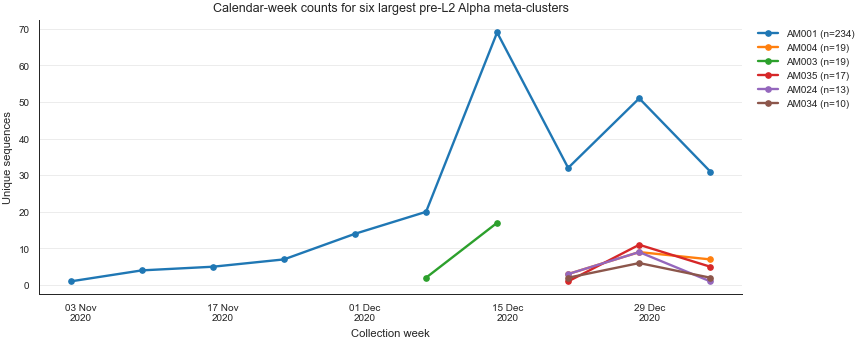

In [9]:
fig, ax = plt.subplots(figsize=(8.8, 3.6))
palette = dict(zip(top_meta, sns.color_palette("tab10", n_colors=len(top_meta))))
for meta in top_meta:
    dat = weekly_counts[weekly_counts["meta_cluster_id"] == meta].sort_values("collection_week")
    label_n = int(top_meta_summary.loc[top_meta_summary["meta_cluster_id"] == meta, "n_alpha_sequences"].iloc[0])
    ax.plot(dat["collection_week"], dat["n_sequences"], marker="o", lw=1.7, ms=3.8, label=f"{meta} (n={label_n})", color=palette[meta])

ax.set_ylabel("Unique sequences")
ax.set_xlabel("Collection week")
ax.set_title("Calendar-week counts for six largest pre-L2 Alpha meta-clusters")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%Y"))
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
ax.grid(axis="y", color="#dddddd", lw=0.5, alpha=0.8)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alpha_top6_meta_cluster_weekly_counts.png", dpi=300)
plt.show()


In [10]:
def plot_weekly_stacked(variable: str, title: str, filename: str, category_order: list[str] | None = None) -> None:
    values = clean_string_category(top[variable])
    if category_order is None:
        category_order = values.value_counts().index.tolist()
    categories = [category for category in category_order if category in set(values)]
    if not categories:
        return

    colors = dict(zip(categories, sns.color_palette("Set2", n_colors=len(categories))))
    fig, axes = plt.subplots(2, 3, figsize=(11, 5.8), sharex=True, sharey=False)
    axes = axes.ravel()

    for ax, meta in zip(axes, top_meta):
        dat = top[top["meta_cluster_id"] == meta].copy()
        dat[variable] = clean_string_category(dat[variable])
        pivot = (
            dat.groupby(["collection_week", variable], observed=False)["sequence_id"]
            .nunique()
            .unstack(fill_value=0)
        )
        for category in categories:
            if category not in pivot.columns:
                pivot[category] = 0
        pivot = pivot[categories].sort_index()

        bottom = np.zeros(len(pivot), dtype=float)
        for category in categories:
            counts = pivot[category].to_numpy(dtype=float)
            ax.bar(pivot.index, counts, bottom=bottom, width=5.5, color=colors[category], label=category, align="center")
            bottom += counts

        total_n = int(top_meta_summary.loc[top_meta_summary["meta_cluster_id"] == meta, "n_alpha_sequences"].iloc[0])
        ax.set_title(f"{meta} (n={total_n})", fontsize=9)
        ax.grid(axis="y", color="#dddddd", lw=0.45, alpha=0.8)
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        if ax in axes[::3]:
            ax.set_ylabel("Unique sequences")

    for ax in axes[len(top_meta):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=min(4, len(categories)), frameon=False)
    fig.suptitle(title, y=1.08, fontsize=11)
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


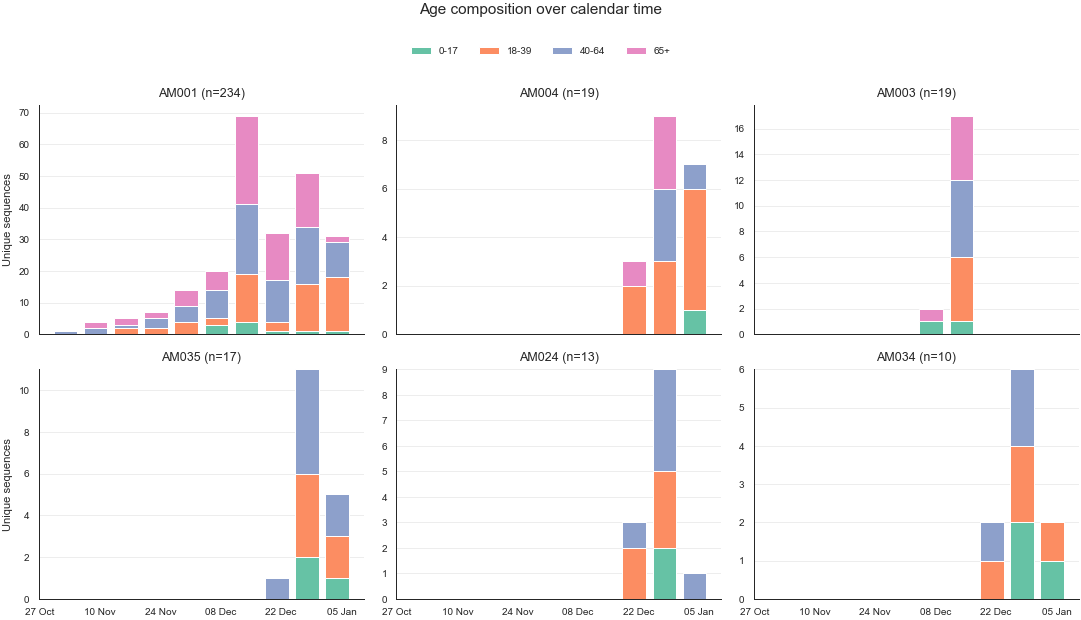

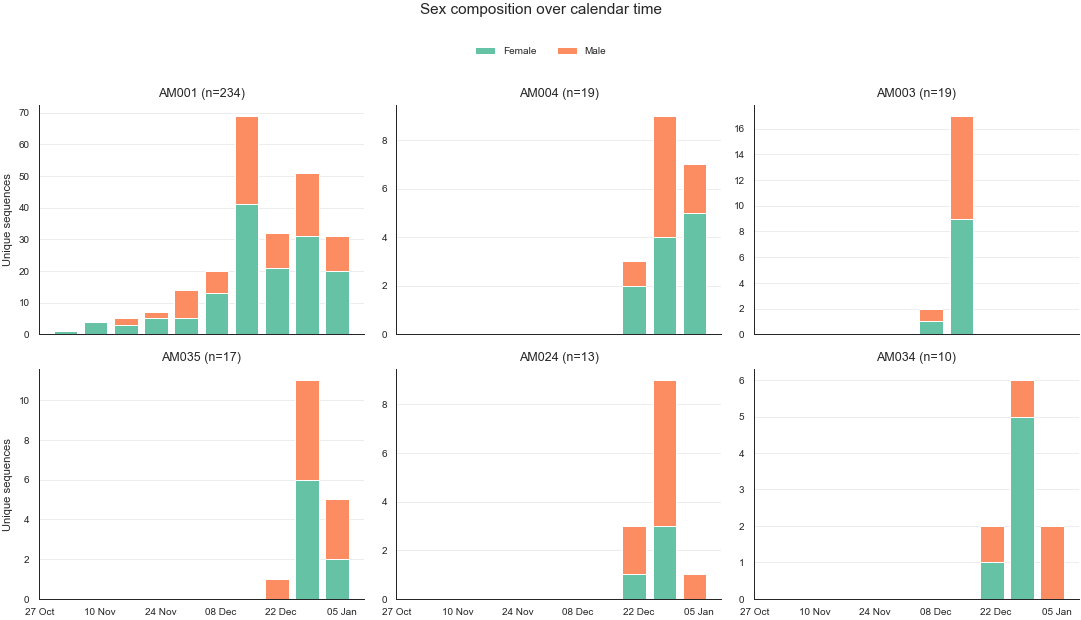

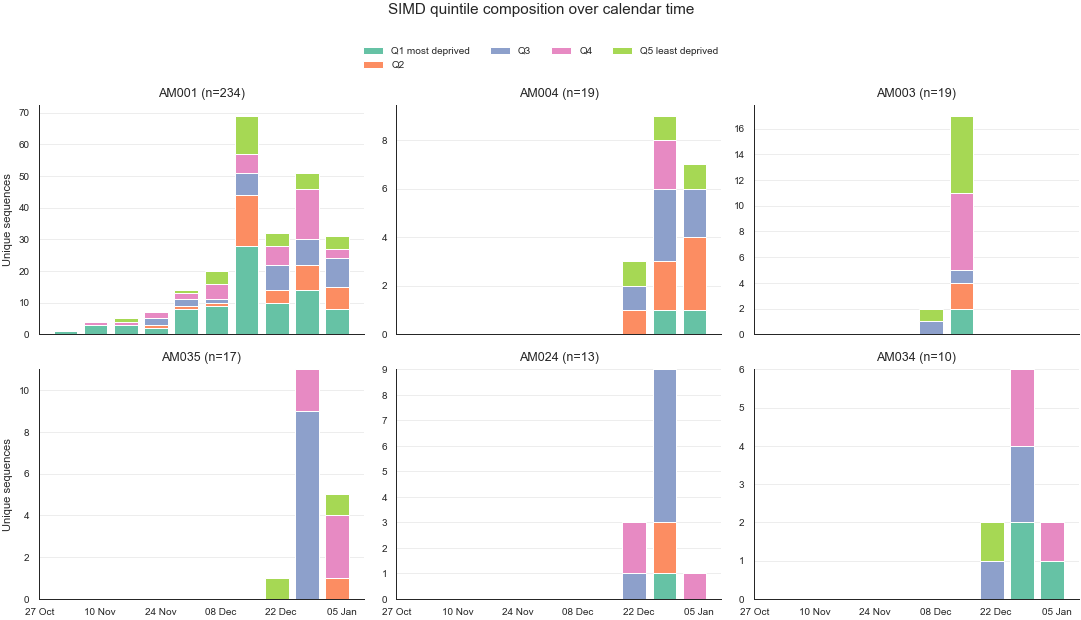

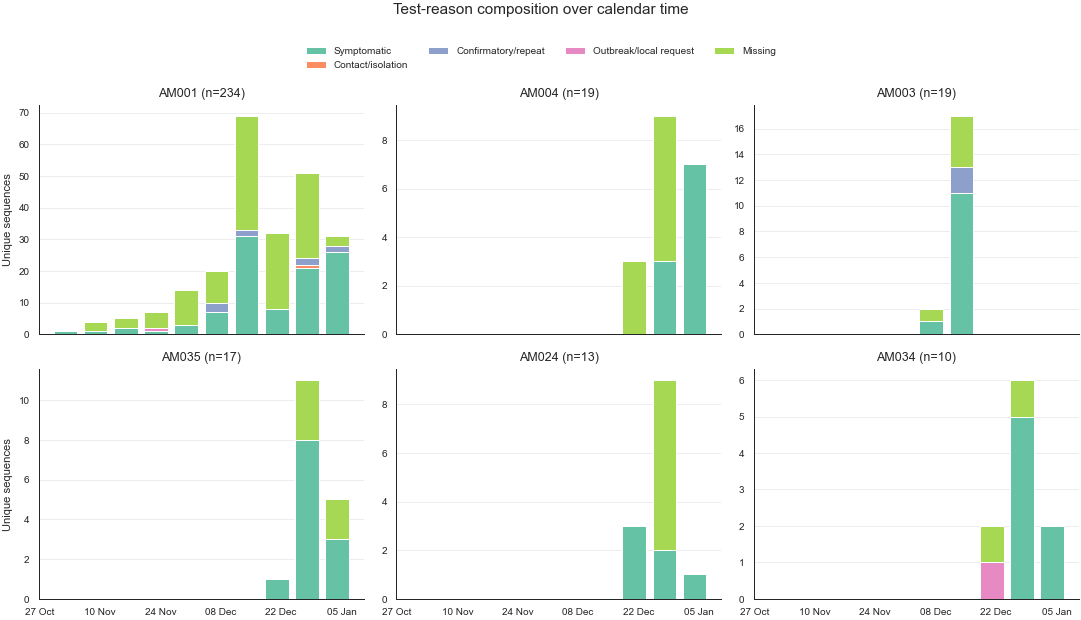

In [11]:
plot_weekly_stacked("age_broad", "Age composition over calendar time", "alpha_top6_meta_cluster_weekly_age_group.png", AGE_BROAD_ORDER)
plot_weekly_stacked("sex_clean", "Sex composition over calendar time", "alpha_top6_meta_cluster_weekly_sex.png", SEX_ORDER)
plot_weekly_stacked("simd_quintile", "SIMD quintile composition over calendar time", "alpha_top6_meta_cluster_weekly_simd_quintile.png", SIMD_ORDER)
plot_weekly_stacked("test_reason_group", "Test-reason composition over calendar time", "alpha_top6_meta_cluster_weekly_test_reason_group.png", TEST_REASON_GROUP_ORDER)


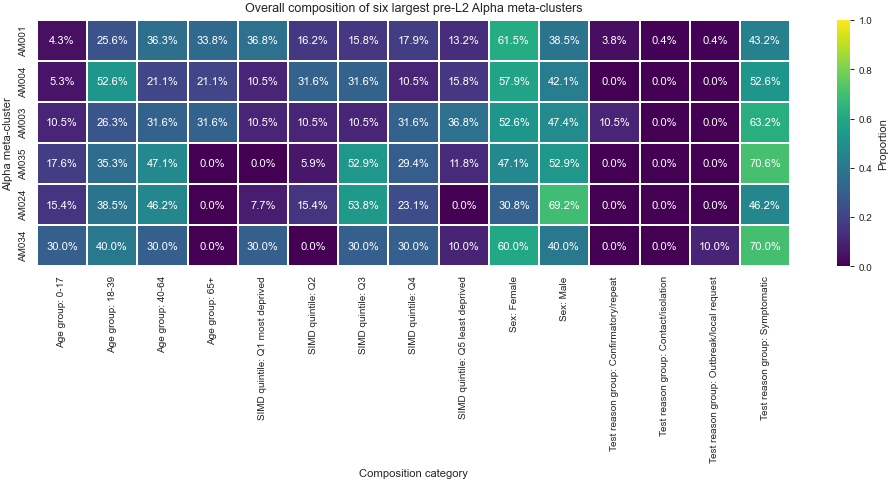

In [16]:
heatmap_vars = ["Age group", "Sex", "SIMD quintile", "Test reason group"]
heatmap_data = overall_composition[overall_composition["variable"].isin(heatmap_vars)].copy()
heatmap_data["label"] = heatmap_data["variable"] + ": " + heatmap_data["category"]
heatmap_data = heatmap_data[heatmap_data["category"] != "Missing"]
matrix = heatmap_data.pivot_table(index="meta_cluster_id", columns="label", values="proportion", fill_value=0)
matrix = matrix.reindex(top_meta)

fig, ax = plt.subplots(figsize=(max(10, 0.35 * matrix.shape[1]), 5))
sns.heatmap(matrix, vmin=0, vmax=1, cmap="viridis",  annot=True, fmt=".1%",
            linewidths=0.25, linecolor="white", cbar_kws={"label": "Proportion"}, ax=ax)
ax.set_xlabel("Composition category")
ax.set_ylabel("Alpha meta-cluster")
ax.set_title("Overall composition of six largest pre-L2 Alpha meta-clusters")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alpha_top6_meta_cluster_overall_composition_heatmap.png", dpi=300)
plt.show()


In [13]:
def top_category_summary(df: pd.DataFrame, variable: str, label: str, top_n: int = 3) -> pd.DataFrame:
    comp = composition_table(df, ["meta_cluster_id"], variable, label)
    return (
        comp.sort_values(["meta_cluster_id", "n_sequences"], ascending=[True, False])
        .groupby("meta_cluster_id")
        .head(top_n)
        .assign(summary=lambda d: d["category"].astype(str) + " (" + d["n_sequences"].astype(str) + ", " + (100 * d["proportion"]).round(1).astype(str) + "%)")
        .groupby("meta_cluster_id")["summary"]
        .apply("; ".join)
        .reset_index(name=f"top_{label.lower().replace(' ', '_')}")
    )


compact_summary = top_meta_summary[["meta_cluster_id", "n_alpha_sequences", "first_collection_date", "last_collection_date"]].copy()
for variable, label in [
    ("age_broad", "Age group"),
    ("sex_clean", "Sex"),
    ("simd_quintile", "SIMD quintile"),
    ("health_board", "Health board"),
    ("test_reason_group", "Test reason group"),
]:
    compact_summary = compact_summary.merge(top_category_summary(top, variable, label), on="meta_cluster_id", how="left")

compact_summary.to_csv(OUTPUT_TABLE_DIR / "alpha_top6_meta_cluster_compact_summary.csv", index=False)
compact_summary


,meta_cluster_id,n_alpha_sequences,first_collection_date,last_collection_date,top_age_group,top_sex,top_simd_quintile,top_health_board,top_test_reason_group
0,AM001,234,2020-11-04,2021-01-04,"40-64 (85, 36.3%); 65+ (79, 33.8%); 18-39 (60,...","Female (144, 61.5%); Male (90, 38.5%)","Q1 most deprived (86, 36.8%); Q4 (42, 17.9%); ...","Greater Glasgow and Clyde (137, 58.5%); Lanark...","Missing (122, 52.1%); Symptomatic (101, 43.2%)..."
1,AM003,19,2020-12-07,2020-12-18,"40-64 (6, 31.6%); 65+ (6, 31.6%); 18-39 (5, 26...","Female (10, 52.6%); Male (9, 47.4%)","Q5 least deprived (7, 36.8%); Q4 (6, 31.6%); Q...","Grampian (14, 73.7%); Lothian (2, 10.5%); Fife...","Symptomatic (12, 63.2%); Missing (5, 26.3%); C..."
2,AM004,19,2020-12-24,2021-01-04,"18-39 (10, 52.6%); 40-64 (4, 21.1%); 65+ (4, 2...","Female (11, 57.9%); Male (8, 42.1%)","Q2 (6, 31.6%); Q3 (6, 31.6%); Q5 least deprive...","Greater Glasgow and Clyde (6, 31.6%); Grampian...","Symptomatic (10, 52.6%); Missing (9, 47.4%)"
3,AM035,17,2020-12-27,2021-01-04,"40-64 (8, 47.1%); 18-39 (6, 35.3%); 0-17 (3, 1...","Male (9, 52.9%); Female (8, 47.1%)","Q3 (9, 52.9%); Q4 (5, 29.4%); Q5 least deprive...","Highland (14, 82.4%); Grampian (1, 5.9%); Grea...","Symptomatic (12, 70.6%); Missing (5, 29.4%)"
4,AM024,13,2020-12-23,2021-01-04,"40-64 (6, 46.2%); 18-39 (5, 38.5%); 0-17 (2, 1...","Male (9, 69.2%); Female (4, 30.8%)","Q3 (7, 53.8%); Q4 (3, 23.1%); Q2 (2, 15.4%)","Borders (13, 100.0%)","Missing (7, 53.8%); Symptomatic (6, 46.2%)"
5,AM034,10,2020-12-27,2021-01-04,"18-39 (4, 40.0%); 0-17 (3, 30.0%); 40-64 (3, 3...","Female (6, 60.0%); Male (4, 40.0%)","Q1 most deprived (3, 30.0%); Q3 (3, 30.0%); Q4...","Greater Glasgow and Clyde (7, 70.0%); Tayside ...","Symptomatic (7, 70.0%); Missing (2, 20.0%); Ou..."
